# Random Forest (1/6) — Random Forest Classification

### The idea in one sentence
> One decision tree can be unstable and overfit. **Train many different trees and let them vote.**

This is the **wisdom of the crowd**: many imperfect but *different* opinions, averaged, beat a single opinion.

### How the trees are made different
1. **Bootstrap sampling:** each tree trains on a random sample of the rows, drawn *with replacement*.
2. **Random features:** at every split, each tree may only look at a random subset of the features.

### In this notebook
1. Train a random forest and evaluate it
2. See individual trees vs the forest
3. **Stability:** forest vs single tree over 20 different data splits
4. How many trees? (`n_estimators`) and the OOB score
5. Tuning and feature importance

> 📖 Theory: [`theory.md`](theory.md) §1–§4, §6 · Deep dive (bagging vs RF, OOB, feature importance, tuning): notebooks 03–06
> · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#FA8072', '#1E90FF']          # 0 = did not buy (salmon), 1 = bought (blue)
CMAP = ListedColormap(COLORS)

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values      # Age, EstimatedSalary
y = dataset.iloc[:, -1].values       # Purchased (0 / 1)
print(dataset.shape)
dataset.head()

(400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


> ✍️ **Core code: learn this.** 75% train, 25% test. No scaling: forests are made of trees.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print(X_train.shape, X_test.shape)

(300, 2) (100, 2)


## 1. Train the random forest

> ✍️ **Core code: learn this.** `n_estimators` = number of trees. 100 is the scikit-learn default and a good starting point.

In [4]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=0)
classifier.fit(X_train, y_train)

print("New customer (30, 87000) ->", classifier.predict([[30, 87000]])[0])
print("Vote share [no, yes]     ->", classifier.predict_proba([[30, 87000]])[0])

New customer (30, 87000) -> 0
Vote share [no, yes]     -> [0.94 0.06]


`predict_proba` is simply the **share of trees** voting for each class (averaged tree probabilities).

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = classifier.predict(X_test)

print("Training accuracy:", accuracy_score(y_train, classifier.predict(X_train)))
print("Test accuracy    :", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred, target_names=['did not buy', 'bought']))

Training accuracy: 1.0
Test accuracy    : 0.92

Confusion matrix:
 [[63  5]
 [ 3 29]]

               precision    recall  f1-score   support

 did not buy       0.95      0.93      0.94        68
      bought       0.85      0.91      0.88        32

    accuracy                           0.92       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.92      0.92      0.92       100



## 2. Individual trees vs the forest

The forest stores its trees in `classifier.estimators_`. Each was trained on a different bootstrap sample, so
each draws a different boundary:

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

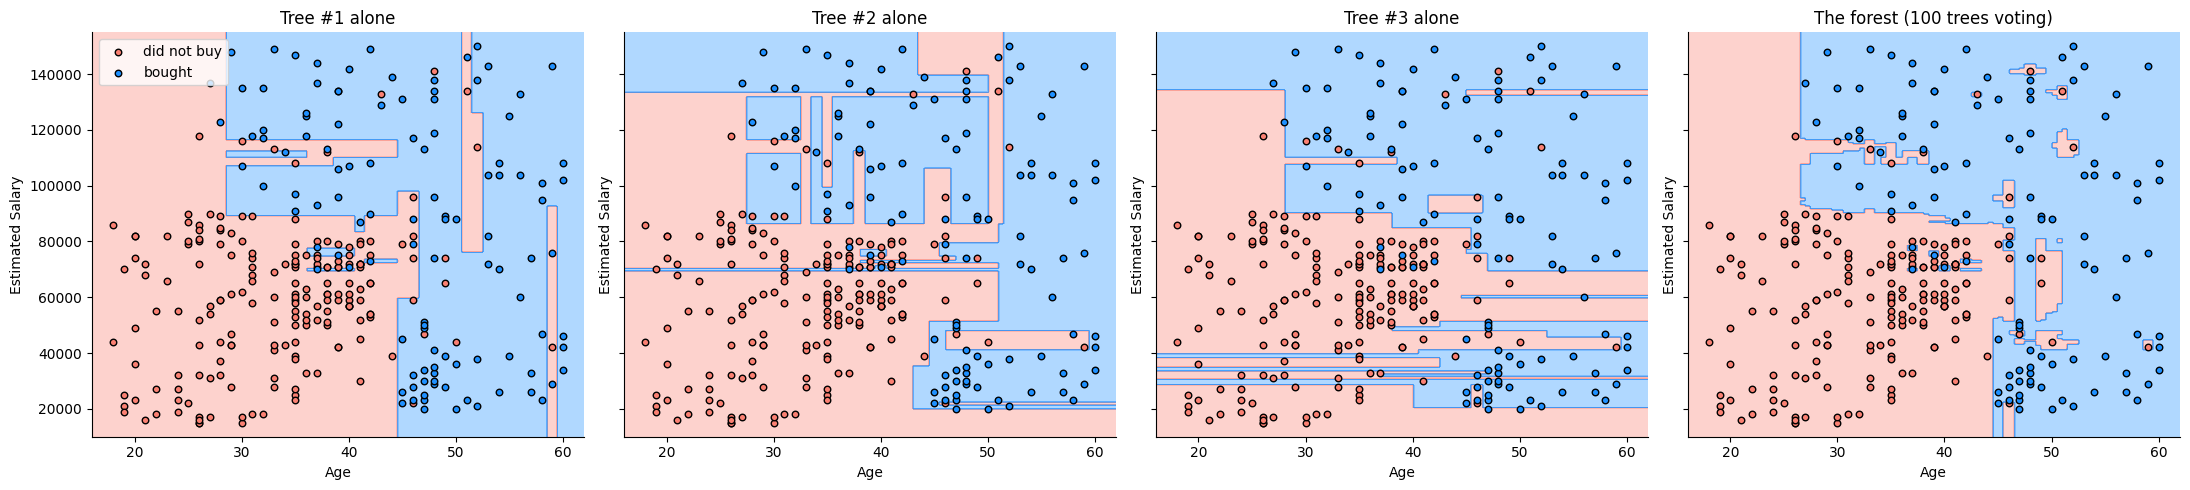

In [6]:
def plot_boundary(ax, model, X_raw, y, title=''):
    # Colour every point of a grid by the model's prediction, then draw the real points on top.
    a = np.linspace(X_raw[:, 0].min() - 2, X_raw[:, 0].max() + 2, 300)
    s = np.linspace(X_raw[:, 1].min() - 5000, X_raw[:, 1].max() + 5000, 300)
    A, S = np.meshgrid(a, s)
    Z = model.predict(np.c_[A.ravel(), S.ravel()]).reshape(A.shape)
    ax.contourf(A, S, Z, alpha=0.35, cmap=CMAP)
    for label in [0, 1]:
        ax.scatter(X_raw[y == label, 0], X_raw[y == label, 1], color=COLORS[label], edgecolor='k',
                   s=22, label=['did not buy', 'bought'][label])
    ax.set_xlabel('Age')
    ax.set_ylabel('Estimated Salary')
    ax.set_title(title)

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, i in zip(axes[:3], [0, 1, 2]):
    plot_boundary(ax, classifier.estimators_[i], X_train, y_train, f'Tree #{i + 1} alone')
plot_boundary(axes[3], classifier, X_train, y_train, 'The forest (100 trees voting)')
axes[0].legend()
plt.tight_layout()
plt.show()

Each single tree has its own random, overfitted islands. In the forest, a quirk of one tree is outvoted by the
others, so the boundary is **smoother and more reliable**: errors that are *different* in each tree cancel out.
The forest still fits the training data closely (training accuracy 1.0, with a few small islands); limiting
`max_depth` (Section 5) smooths it further.

## 3. Stability: one tree vs a forest over 20 different splits

A good model should not depend heavily on *which* rows ended up in the test set. We repeat the whole experiment with
20 different random train/test splits.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

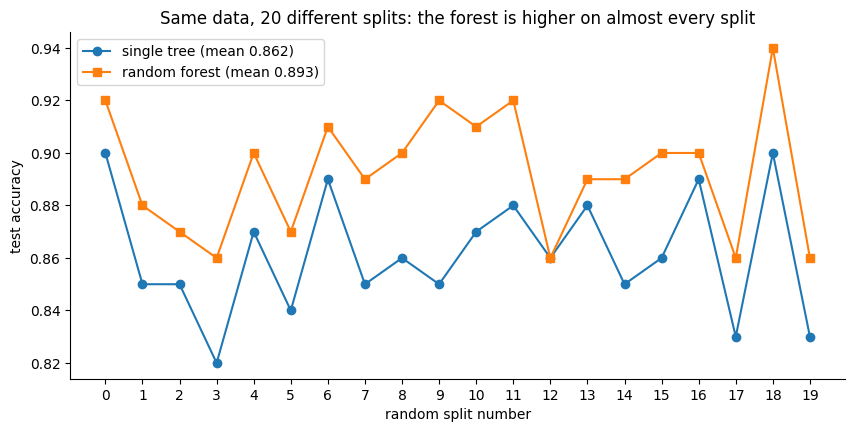

Splits where the forest beats or ties the tree: 20 of 20


In [7]:
from sklearn.tree import DecisionTreeClassifier

tree_acc, forest_acc = [], []
for seed in range(20):
    a, b, c, d = train_test_split(X, y, test_size=0.25, random_state=seed)
    tree_acc.append(DecisionTreeClassifier(random_state=seed).fit(a, c).score(b, d))
    forest_acc.append(RandomForestClassifier(random_state=seed).fit(a, c).score(b, d))

plt.figure(figsize=(10, 4.5))
plt.plot(range(20), tree_acc, 'o-', label=f'single tree (mean {np.mean(tree_acc):.3f})')
plt.plot(range(20), forest_acc, 's-', label=f'random forest (mean {np.mean(forest_acc):.3f})')
plt.xlabel('random split number')
plt.ylabel('test accuracy')
plt.xticks(range(20))
plt.title('Same data, 20 different splits: the forest is higher on almost every split')
plt.legend()
plt.show()

print("Splits where the forest beats or ties the tree:", sum(f >= t for f, t in zip(forest_acc, tree_acc)), "of 20")

Without any tuning, the forest is about **3 percentage points** more accurate than a single unrestricted tree
on average. This is the main reason random forests are so popular: **good results with little tuning**.

## 4. How many trees?

More trees never cause overfitting; they just make the vote more stable (and training slower).
The **OOB (out-of-bag) score** is a free validation score: each tree is tested on the rows it did *not* see in its
bootstrap sample (theory §4).

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

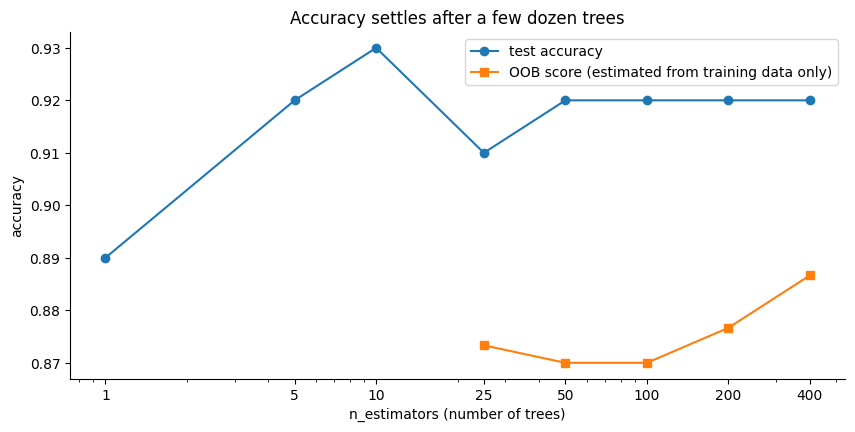

In [8]:
ns = [1, 5, 10, 25, 50, 100, 200, 400]
test_acc, oob = [], []
for n in ns:
    m = RandomForestClassifier(n_estimators=n, oob_score=n >= 25, random_state=0).fit(X_train, y_train)
    test_acc.append(m.score(X_test, y_test))
    oob.append(m.oob_score_ if n >= 25 else np.nan)

plt.figure(figsize=(10, 4.5))
plt.plot(ns, test_acc, 'o-', label='test accuracy')
plt.plot(ns, oob, 's-', label='OOB score (estimated from training data only)')
plt.xscale('log')
plt.xticks(ns, ns)
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('accuracy')
plt.title('Accuracy settles after a few dozen trees')
plt.legend()
plt.show()

With very few trees the result jumps around. From about 50 trees the test accuracy is flat at 0.92, and the OOB
score creeps up slowly as the vote becomes more stable. Adding trees costs time but does not overfit.

## 5. Tuning the forest

> ✍️ **Core code: learn this.** The most useful settings to tune.

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_leaf': [1, 5, 10],
}
search = GridSearchCV(RandomForestClassifier(random_state=0), param_grid, cv=5)
search.fit(X_train, y_train)

print("Best parameters :", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 3))
print("Test accuracy   :", search.score(X_test, y_test))

Best parameters : {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV accuracy: 0.907
Test accuracy   : 0.94


> ✍️ **Core code: learn this.** Feature importance: how much each feature helped, averaged over all trees.

In [10]:
pd.Series(search.best_estimator_.feature_importances_, index=['Age', 'EstimatedSalary']).round(3)

Age                0.543
EstimatedSalary    0.457
dtype: float64

Both features matter. (Notebook `05-feature-importance.ipynb` explains how these importances are calculated and their pitfalls.)

---
## Key takeaways
- Random forest = **many decision trees**, each trained on a **bootstrap sample** with **random features** per split,
  combined by **majority vote**.
- Individual trees overfit in *different* ways; voting cancels those errors, giving a **smoother, more stable** model.
- More trees never overfit; tune `max_depth`, `min_samples_leaf` and `max_features` for the best results.
- No scaling needed; you get `feature_importances_` and a free **OOB score**.

## 🧠 Quick check

<details><summary>1. What two sources of randomness make the trees different?</summary>

Bootstrap samples of the rows, and a random subset of features considered at each split.
</details>

<details><summary>2. Can adding more trees cause overfitting?</summary>

No. More trees only make the vote more stable; the cost is training and prediction time.
</details>

<details><summary>3. What is the OOB score?</summary>

Accuracy measured on the rows each tree did not see during training: a built-in validation score.
</details>

➡️ **Next:** `02-random-forest-regression.ipynb`